In [2]:
# ============================================================
# segmentation_02_clustering.py
# Olist – Clustering clients | base_final1.csv (96 096 × 17)
# ============================================================

# ── 0. IMPORTS ───────────────────────────────────────────────
import warnings, json, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import RobustScaler, StandardScaler, PowerTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import (
    KMeans, MiniBatchKMeans, AgglomerativeClustering,
    DBSCAN, OPTICS, Birch
)
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score
)

# Install mlflow if not already installed
!pip install mlflow
import mlflow, mlflow.sklearn
from mlflow.models.signature import infer_signature

try:
    from kneed import KneeLocator; HAS_KNEED = True
except ImportError:
    HAS_KNEED = False

try:
    import umap; HAS_UMAP = True
except ImportError:
    HAS_UMAP = False

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

for d in ['models', 'figures', 'reports']:
    Path(d).mkdir(exist_ok=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 654.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.2/866.2 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2

In [3]:
# ── 1. CHARGEMENT ─────────────────────────────────────────────
df_raw = pd.read_csv('../data/Base.csv')
print(f'Shape : {df_raw.shape}')   # (96096, 17)
print(df_raw.isna().sum())

Shape : (96096, 31)
customer_unique_id                       0
Recency                                  0
Frequency                                0
Monetary                                 0
avg_delivery_days                        0
late_delivery_rate                       0
avg_review_score                         0
preferred_payment                        0
avg_installments                         0
product_diversity                        0
avg_item_price                         676
avg_freight_value                        0
preferred_category                       0
avg_lat                                268
avg_lng                                268
avg_freight_ratio                      676
std_freight_ratio                        0
avg_delivery_delta                    2740
review_participation_rate                0
recency_ratio                        96096
CLV_estimate                             0
is_repeat_customer                       0
never_delivered                   

In [5]:
# ── 2. PRÉPARATION ────────────────────────────────────────────

# 2.1 Encodage preferred_payment
payment_map = {'credit_card': 4, 'debit_card': 3, 'voucher': 2, 'boleto': 1}
df = df_raw.copy()
df['preferred_payment_enc'] = df['preferred_payment'].map(payment_map).fillna(1).astype(int)

# 2.2 Remplissage NA par médiane
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols] = df[num_cols].fillna(df[num_cols].median())
print(f'NA restants : {df[num_cols].isna().sum().sum()}')

# 2.3 Winsorisation
def cap_outliers(df, cols, q=0.99):
    df = df.copy()
    for col in cols:
        df[col] = df[col].clip(lower=df[col].quantile(1-q),
                                upper=df[col].quantile(q))
    return df

# 2.4 Normalisation
def prepare_data(df, feature_cols, scaler_type='robust'):
    X = cap_outliers(df, feature_cols)[feature_cols].values
    scalers = {
        'robust':   RobustScaler(),
        'standard': StandardScaler(),
        'power':    PowerTransformer(method='yeo-johnson')
    }
    scaler = scalers[scaler_type]
    return scaler.fit_transform(X), scaler

# ── 2.5 TROIS CONFIGURATIONS DE VARIABLES ────────────────────
FEATURES_RFM = ['Recency', 'Frequency', 'Monetary']

FEATURES_EXTENDED = [
    'Recency', 'Frequency', 'Monetary',
    'avg_delivery_days', 'late_delivery_rate',
    'avg_review_score', 'avg_installments',
    'product_diversity', 'CLV_estimate'
]

FEATURES_FULL = [
    'Recency', 'Frequency', 'Monetary',
    'avg_delivery_days', 'late_delivery_rate', 'avg_review_score',
    'preferred_payment_enc', 'avg_installments', 'product_diversity',
    'avg_item_price', 'avg_freight_value', # Removed 'num_unique_sellers',
    # Removed 'customer_tenure', 'payment_value_std',
    'CLV_estimate', 'is_repeat_customer'
]

FEATURE_SETS = {'RFM': FEATURES_RFM, 'Extended': FEATURES_EXTENDED, 'Full': FEATURES_FULL}

prepared = {}
for name, cols in FEATURE_SETS.items():
    X_s, sc = prepare_data(df, cols, 'robust')
    prepared[name] = {'X': X_s, 'scaler': sc, 'cols': cols}
    print(f'{name:10s} → {len(cols):2d} vars | {X_s.shape}')

X_ext, sc_ext, cols_ext = (prepared['Extended']['X'],
                             prepared['Extended']['scaler'],
                             prepared['Extended']['cols'])

# ── 2.6 RÉDUCTIONS ────────────────────────────────────────────
pca = PCA(n_components=min(10, X_ext.shape[1]), random_state=RANDOM_STATE)
X_pca_full = pca.fit_transform(X_ext)
X_pca_2d   = X_pca_full[:, :2]
cumvar     = np.cumsum(pca.explained_variance_ratio_)
n_comp_90  = int(np.argmax(cumvar >= 0.90)) + 1
X_pca_90   = X_pca_full[:, :n_comp_90]
print(f'{n_comp_90} composantes PCA pour 90% variance')

idx_tsne  = np.random.choice(len(X_ext), 10_000, replace=False)
tsne      = TSNE(n_components=2, perplexity=40, learning_rate='auto',
                  init='pca', random_state=RANDOM_STATE, n_jobs=-1)
X_tsne_2d = tsne.fit_transform(X_ext[idx_tsne])

if HAS_UMAP:
    reducer   = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                           random_state=RANDOM_STATE)
    X_umap_2d = reducer.fit_transform(X_ext)
else:
    X_umap_2d = X_pca_2d
    print('Fallback PCA 2D')

NA restants : 96096
RFM        →  3 vars | (96096, 3)
Extended   →  9 vars | (96096, 9)
Full       → 13 vars | (96096, 13)
4 composantes PCA pour 90% variance


In [6]:
# ── 3. FONCTIONS UTILITAIRES ──────────────────────────────────

def evaluate_clustering(X, labels):
    mask       = labels != -1
    n_clusters = len(set(labels[mask]))
    n_noise    = int(np.sum(labels == -1))
    if n_clusters < 2:
        return {'n_clusters': n_clusters, 'n_noise': n_noise,
                'silhouette': np.nan, 'davies_bouldin': np.nan,
                'calinski_harabasz': np.nan}
    if mask.sum() > 30_000:
        idx = np.random.choice(np.where(mask)[0], 30_000, replace=False)
        X_s, l_s = X[idx], labels[idx]
    else:
        X_s, l_s = X[mask], labels[mask]
    return {
        'n_clusters':        n_clusters,
        'n_noise':           n_noise,
        'silhouette':        round(silhouette_score(X_s, l_s), 4),
        'davies_bouldin':    round(davies_bouldin_score(X[mask], labels[mask]), 4),
        'calinski_harabasz': round(calinski_harabasz_score(X[mask], labels[mask]), 2)
    }


def plot_clusters_2d(coords, labels, title, method='UMAP', save_path=None):
    unique  = sorted(set(labels))
    palette = plt.cm.get_cmap('tab10', max(len(unique), 10))
    fig, ax = plt.subplots(figsize=(9, 6))
    for i, lab in enumerate(unique):
        mask  = labels == lab
        color = 'lightgrey' if lab == -1 else palette(i)
        lbl   = f'Bruit ({mask.sum():,})' if lab == -1 else f'Cluster {lab} ({mask.sum():,})'
        ax.scatter(coords[mask,0], coords[mask,1], c=[color], label=lbl, s=5, alpha=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel(f'{method} 1'); ax.set_ylabel(f'{method} 2')
    ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8, markerscale=2)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_silhouette(X, labels, title, max_pts=20_000):
    mask    = labels != -1
    X_, l_  = X[mask], labels[mask]
    if len(X_) > max_pts:
        idx = np.random.choice(len(X_), max_pts, replace=False)
        X_, l_ = X_[idx], l_[idx]
    sil_vals = silhouette_samples(X_, l_)
    avg      = sil_vals.mean()
    palette  = plt.cm.get_cmap('tab10', len(set(l_)))
    fig, ax  = plt.subplots(figsize=(8, 5))
    y_lower  = 10
    for i, lab in enumerate(sorted(set(l_))):
        vals    = np.sort(sil_vals[l_ == lab])
        y_upper = y_lower + vals.shape[0]
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals,
                         facecolor=palette(i), alpha=0.7, label=f'C{lab}')
        y_lower = y_upper + 10
    ax.axvline(avg, color='red', ls='--', label=f'Moy={avg:.3f}')
    ax.set_title(f'Silhouette — {title}')
    ax.set_xlabel('Score'); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

In [7]:
# ── 4. MLFLOW ─────────────────────────────────────────────────
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('olist_segmentation')
ALL_RESULTS = []


def mlflow_log(run_name, algorithm, feature_set, params, metrics,
               model, X, labels, scaler, feature_cols):
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({'algorithm': algorithm, 'feature_set': feature_set,
                         'n_samples': X.shape[0], 'n_features': X.shape[1]})
        mlflow.log_params({**params, 'feature_cols': json.dumps(feature_cols)})
        mlflow.log_metrics({k: float(v) for k, v in metrics.items()
                             if isinstance(v, (int, float)) and not np.isnan(v)})
        # pkl pipeline
        pkl_path = f'models/{run_name}.pkl'
        with open(pkl_path, 'wb') as f:
            pickle.dump({'model': model, 'scaler': scaler,
                         'feature_cols': feature_cols}, f)
        mlflow.log_artifact(pkl_path)
        try:
            mlflow.sklearn.log_model(model, 'sklearn_model')
        except Exception:
            pass
        return mlflow.active_run().info.run_id

2026/04/24 01:26:20 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/24 01:26:20 INFO mlflow.store.db.utils: Updating database tables
2026/04/24 01:26:23 INFO mlflow.tracking.fluent: Experiment with name 'olist_segmentation' does not exist. Creating a new experiment.


k optimal KMeans : 5


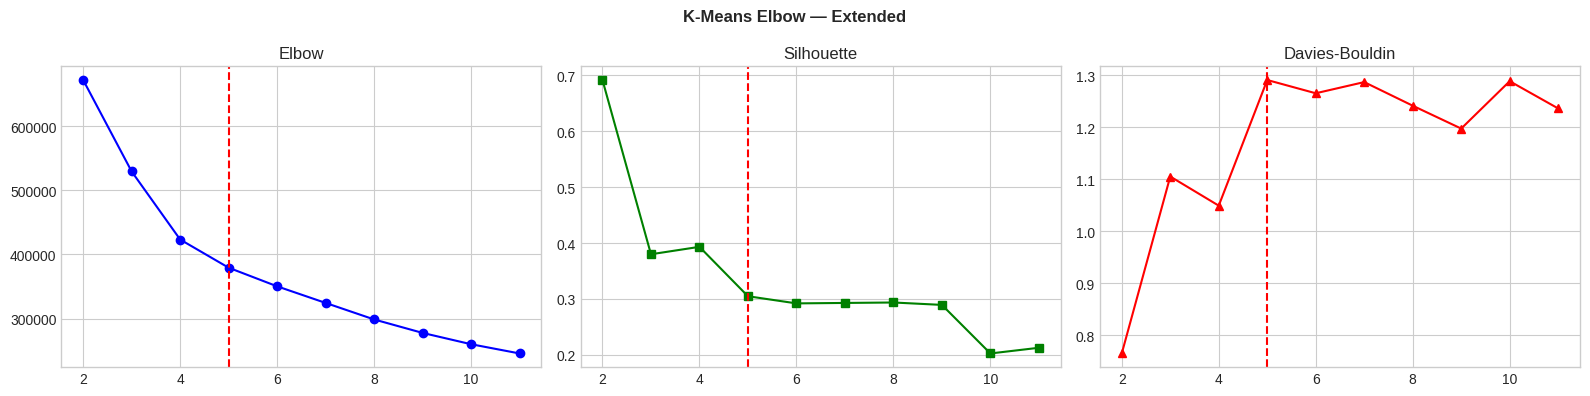

2026/04/24 01:28:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:28:59 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KMeans_k4_Extended sil=0.3896


2026/04/24 01:29:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:29:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KMeans_k5_Extended sil=0.2997


2026/04/24 01:29:37 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:29:37 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KMeans_k6_Extended sil=0.2896


2026/04/24 01:29:56 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:29:56 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KMeans_k7_Extended sil=0.2920


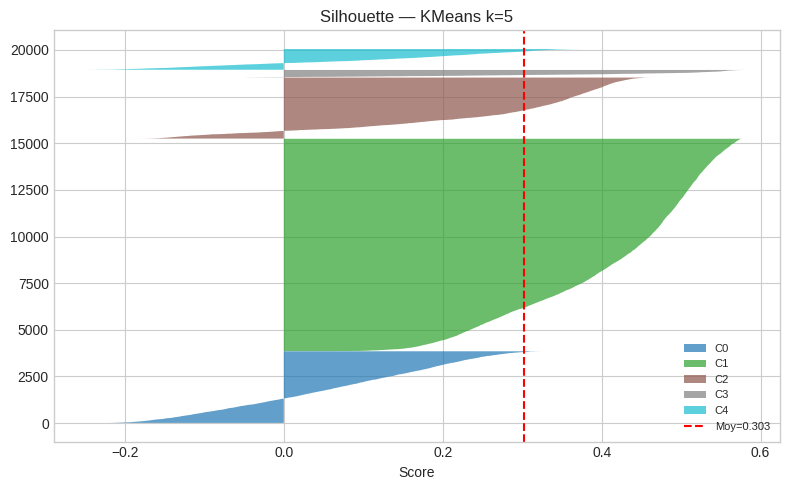

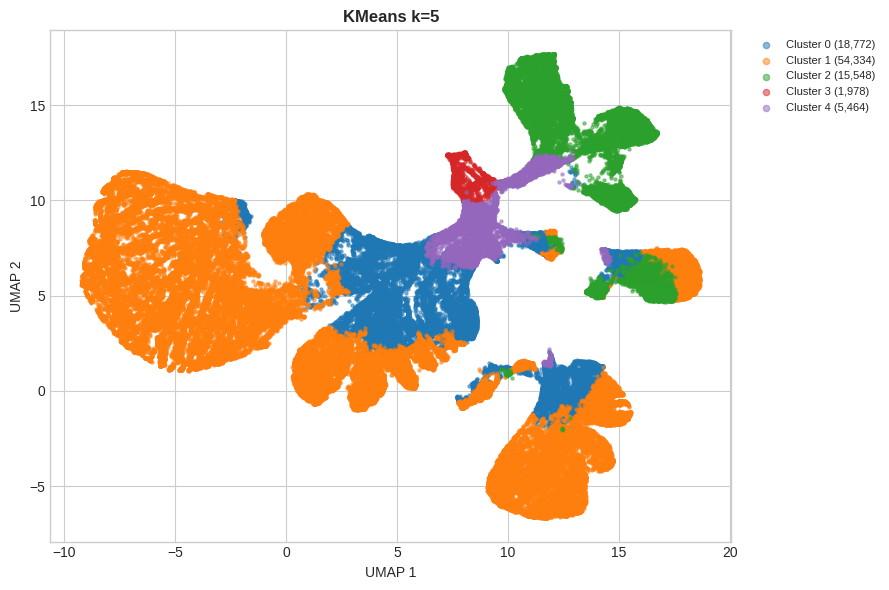

In [8]:
# ── 5. ALGORITHMES ────────────────────────────────────────────

# 5.1 K-Means Elbow
K_RANGE = range(2, 12)
inertias, sils_km, dbs_km = [], [], []
for k in K_RANGE:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10,
                    max_iter=300, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_ext)
    m      = evaluate_clustering(X_ext, labels)
    inertias.append(km.inertia_)
    sils_km.append(m['silhouette'])
    dbs_km.append(m['davies_bouldin'])

if HAS_KNEED:
    kn    = KneeLocator(list(K_RANGE), inertias, curve='convex', direction='decreasing')
    K_OPT = kn.knee or 4
else:
    K_OPT = list(K_RANGE)[np.argmax(np.diff(inertias, 2)) + 2]
print(f'k optimal KMeans : {K_OPT}')

# Elbow plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(K_RANGE, inertias, 'bo-'); axes[0].axvline(K_OPT, color='red', ls='--'); axes[0].set_title('Elbow')
axes[1].plot(K_RANGE, sils_km, 'gs-');  axes[1].axvline(K_OPT, color='red', ls='--'); axes[1].set_title('Silhouette')
axes[2].plot(K_RANGE, dbs_km, 'r^-');   axes[2].axvline(K_OPT, color='red', ls='--'); axes[2].set_title('Davies-Bouldin')
plt.suptitle('K-Means Elbow — Extended', fontweight='bold')
plt.tight_layout(); plt.savefig('figures/kmeans_elbow.png', dpi=150); plt.show()

# Logger k candidats KMeans
for k in sorted({K_OPT-1, K_OPT, K_OPT+1, K_OPT+2} - {1}):
    km     = KMeans(n_clusters=k, init='k-means++', n_init=15, max_iter=500, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_ext)
    m      = evaluate_clustering(X_ext, labels)
    rn     = f'KMeans_k{k}_Extended'
    rid    = mlflow_log(rn, 'KMeans', 'Extended', {'k': k}, m, km, X_ext, labels, sc_ext, cols_ext)
    m.update({'run_name': rn, 'algorithm': 'KMeans', 'feature_set': 'Extended', 'k': k, 'run_id': rid})
    ALL_RESULTS.append(m)
    print(f'{rn} sil={m["silhouette"]:.4f}')

# Visualisation k optimal
labels_km_best = KMeans(n_clusters=K_OPT, init='k-means++', n_init=15, random_state=RANDOM_STATE).fit_predict(X_ext)
plot_silhouette(X_ext, labels_km_best, f'KMeans k={K_OPT}')
plot_clusters_2d(X_umap_2d, labels_km_best, f'KMeans k={K_OPT}', save_path=f'figures/kmeans_k{K_OPT}_umap.png')


In [9]:
# 5.2 KMeans sur 3 configs
for fs_name, fs_data in prepared.items():
    for k in [K_OPT, K_OPT+1]:
        km     = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
        labels = km.fit_predict(fs_data['X'])
        m      = evaluate_clustering(fs_data['X'], labels)
        rn     = f'KMeans_k{k}_{fs_name}'
        rid    = mlflow_log(rn, 'KMeans', fs_name, {'k': k}, m, km, fs_data['X'], labels, fs_data['scaler'], fs_data['cols'])
        m.update({'run_name': rn, 'algorithm': 'KMeans', 'feature_set': fs_name, 'k': k, 'run_id': rid})
        ALL_RESULTS.append(m)
        print(f'{rn} sil={m["silhouette"]:.4f}')

2026/04/24 01:38:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:38:32 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KMeans_k5_RFM sil=0.4110


2026/04/24 01:38:48 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:38:48 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KMeans_k6_RFM sil=0.4062


2026/04/24 01:39:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:39:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


...

KMeans_k6_Extended sil=0.2872


2026/04/24 01:39:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:39:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KMeans_k5_Full sil=0.2777


2026/04/24 01:39:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:39:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KMeans_k6_Full sil=0.2874


In [10]:
# 5.3 KMeans + PCA
for k in [K_OPT, K_OPT+1]:
    km     = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca_90)
    m      = evaluate_clustering(X_pca_90, labels)
    rn     = f'KMeans_PCA{n_comp_90}_k{k}_Extended'
    rid    = mlflow_log(rn, 'KMeans+PCA', 'Extended', {'k': k, 'n_pca': n_comp_90}, m, km, X_pca_90, labels, sc_ext, cols_ext)
    m.update({'run_name': rn, 'algorithm': 'KMeans+PCA', 'feature_set': 'Extended', 'k': k, 'run_id': rid})
    ALL_RESULTS.append(m)
    print(f'{rn} sil={m["silhouette"]:.4f}')



2026/04/24 01:40:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:40:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KMeans_PCA4_k5_Extended sil=0.3760


2026/04/24 01:40:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:40:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


KMeans_PCA4_k6_Extended sil=0.3749


In [11]:
# 5.4 MiniBatch KMeans
for k in [K_OPT, K_OPT+1]:
    mbkm   = MiniBatchKMeans(n_clusters=k, batch_size=2048, n_init=10, random_state=RANDOM_STATE)
    labels = mbkm.fit_predict(X_ext)
    m      = evaluate_clustering(X_ext, labels)
    rn     = f'MiniBatchKMeans_k{k}_Extended'
    rid    = mlflow_log(rn, 'MiniBatchKMeans', 'Extended', {'k': k, 'batch_size': 2048}, m, mbkm, X_ext, labels, sc_ext, cols_ext)
    m.update({'run_name': rn, 'algorithm': 'MiniBatchKMeans', 'feature_set': 'Extended', 'k': k, 'run_id': rid})
    ALL_RESULTS.append(m)



2026/04/24 01:40:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:40:47 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/24 01:41:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/24 01:41:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_p

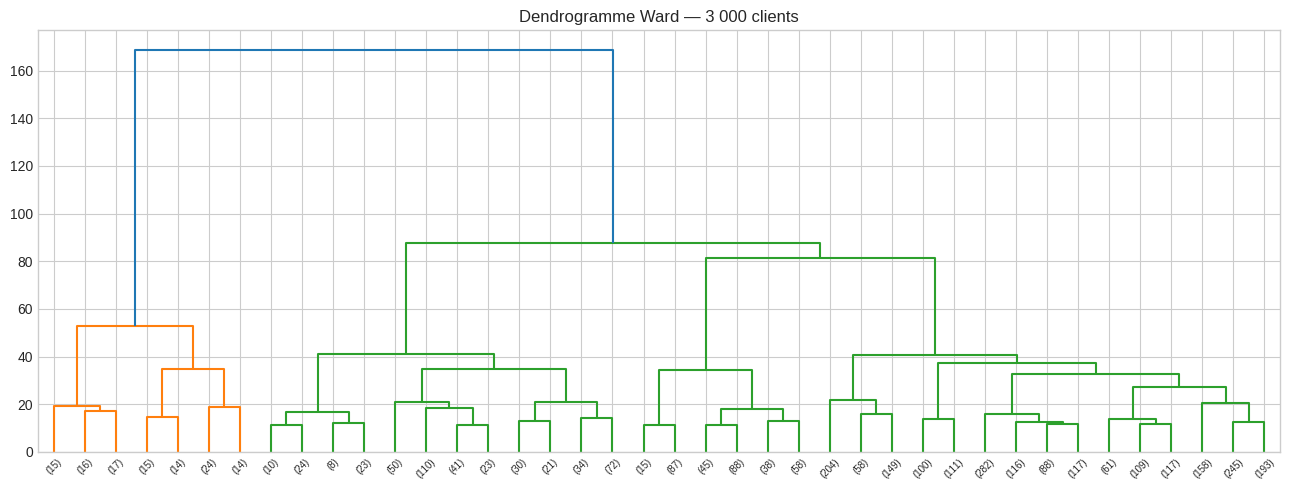

In [ ]:
# 5.5 Agglomératif + Dendrogramme
idx_d = np.random.choice(len(X_ext), 3_000, replace=False)
Z     = linkage(X_ext[idx_d], method='ward')
plt.figure(figsize=(13, 5))
dendrogram(Z, truncate_mode='lastp', p=40, leaf_rotation=45, leaf_font_size=7)
plt.title('Dendrogramme Ward — 3 000 clients'); plt.tight_layout()
plt.savefig('figures/dendrogramme.png', dpi=150); plt.show()

for linkage_m in ['ward', 'complete', 'average']:
    for k in [K_OPT, K_OPT+1]:
        agg    = AgglomerativeClustering(n_clusters=k, linkage=linkage_m)
        labels = agg.fit_predict(X_ext)
        m      = evaluate_clustering(X_ext, labels)
        rn     = f'Agglo_{linkage_m}_k{k}_Extended'
        rid    = mlflow_log(rn, 'Agglomerative', 'Extended', {'k': k, 'linkage': linkage_m}, m, agg, X_ext, labels, sc_ext, cols_ext)
        m.update({'run_name': rn, 'algorithm': f'Agglo_{linkage_m}', 'feature_set': 'Extended', 'k': k, 'run_id': rid})
        ALL_RESULTS.append(m)
        print(f'{rn} sil={m["silhouette"]:.4f}')



In [ ]:
# 5.6 DBSCAN
nbrs          = NearestNeighbors(n_neighbors=5, n_jobs=-1).fit(X_ext)
dist5, _      = nbrs.kneighbors(X_ext)
dist5_sorted  = np.sort(dist5[:, 4])
EPS_OPT       = (float(dist5_sorted[KneeLocator(range(len(dist5_sorted)), dist5_sorted,
                                                  curve='convex', direction='increasing').knee])
                 if HAS_KNEED else float(np.percentile(dist5_sorted, 90)))
print(f'ε DBSCAN : {EPS_OPT:.4f}')

for eps, ms in [(round(EPS_OPT*0.8,3),5),(round(EPS_OPT*0.8,3),10),(round(EPS_OPT,3),5),
                (round(EPS_OPT,3),10),(round(EPS_OPT,3),20),(round(EPS_OPT*1.2,3),10)]:
    dbs    = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
    labels = dbs.fit_predict(X_ext)
    m      = evaluate_clustering(X_ext, labels)
    rn     = f'DBSCAN_eps{eps}_ms{ms}'
    print(f'{rn} → clusters={m["n_clusters"]} bruit={m["n_noise"]:,} sil={m["silhouette"]}')
    if m['n_clusters'] >= 2:
        rid = mlflow_log(rn, 'DBSCAN', 'Extended', {'eps': eps, 'min_samples': ms}, m, dbs, X_ext, labels, sc_ext, cols_ext)
        m.update({'run_name': rn, 'algorithm': 'DBSCAN', 'feature_set': 'Extended', 'run_id': rid})
        ALL_RESULTS.append(m)



In [ ]:
# 5.7 OPTICS
optics        = OPTICS(min_samples=15, xi=0.05, min_cluster_size=0.03, n_jobs=-1)
labels_optics = optics.fit_predict(X_ext)
m             = evaluate_clustering(X_ext, labels_optics)
print('OPTICS :', m)
if m['n_clusters'] >= 2:
    rid = mlflow_log('OPTICS_Extended', 'OPTICS', 'Extended', {'min_samples':15,'xi':0.05}, m, optics, X_ext, labels_optics, sc_ext, cols_ext)
    m.update({'run_name': 'OPTICS_Extended', 'algorithm': 'OPTICS', 'feature_set': 'Extended', 'run_id': rid})
    ALL_RESULTS.append(m)



In [ ]:
# 5.8 GMM
bics, aics = [], []
for k in range(2, 10):
    gmm = GaussianMixture(n_components=k, covariance_type='full', n_init=3, random_state=RANDOM_STATE)
    gmm.fit(X_ext); bics.append(gmm.bic(X_ext)); aics.append(gmm.aic(X_ext))
K_GMM_OPT = list(range(2,10))[np.argmin(bics)]
print(f'k GMM optimal : {K_GMM_OPT}')

for cov in ['full','tied','diag']:
    for k in [K_GMM_OPT, K_GMM_OPT+1]:
        gmm    = GaussianMixture(n_components=k, covariance_type=cov, n_init=5, random_state=RANDOM_STATE)
        labels = gmm.fit_predict(X_ext)
        m      = evaluate_clustering(X_ext, labels)
        rn     = f'GMM_{cov}_k{k}_Extended'
        rid    = mlflow_log(rn, 'GMM', 'Extended', {'k': k, 'covariance_type': cov}, m, gmm, X_ext, labels, sc_ext, cols_ext)
        m.update({'run_name': rn, 'algorithm': f'GMM_{cov}', 'feature_set': 'Extended', 'k': k, 'run_id': rid})
        ALL_RESULTS.append(m)



In [ ]:
# 5.9 Bayesian GMM
bgmm        = BayesianGaussianMixture(n_components=10, covariance_type='full',
                                       weight_concentration_prior_type='dirichlet_process',
                                       weight_concentration_prior=1e-3, n_init=3,
                                       random_state=RANDOM_STATE)
labels_bgmm = bgmm.fit_predict(X_ext)
m           = evaluate_clustering(X_ext, labels_bgmm)
print('BayesianGMM :', m)
rid = mlflow_log('BayesianGMM_Extended', 'BayesianGMM', 'Extended',
                 {'max_components':10}, m, bgmm, X_ext, labels_bgmm, sc_ext, cols_ext)
m.update({'run_name':'BayesianGMM_Extended','algorithm':'BayesianGMM','feature_set':'Extended','run_id':rid})
ALL_RESULTS.append(m)

In [ ]:
# 5.10 BIRCH
for k in [K_OPT, K_OPT+1]:
    for thr in [0.3, 0.5, 0.7]:
        birch  = Birch(n_clusters=k, threshold=thr)
        labels = birch.fit_predict(X_ext)
        m      = evaluate_clustering(X_ext, labels)
        rn     = f'BIRCH_k{k}_thr{thr}_Extended'
        rid    = mlflow_log(rn, 'BIRCH', 'Extended', {'k': k, 'threshold': thr}, m, birch, X_ext, labels, sc_ext, cols_ext)
        m.update({'run_name': rn, 'algorithm': 'BIRCH', 'feature_set': 'Extended', 'k': k, 'run_id': rid})
        ALL_RESULTS.append(m)

In [ ]:
# ── 6. COMPARAISON ────────────────────────────────────────────
df_comp = pd.DataFrame(ALL_RESULTS).sort_values('silhouette', ascending=False).reset_index(drop=True)
df_comp.to_csv('reports/clustering_comparison.csv', index=False)
print('\n=== TOP 20 (Silhouette) ===')
print(df_comp[['run_name','n_clusters','n_noise','silhouette','davies_bouldin','calinski_harabasz']].head(20).to_string(index=False))

# Heatmap
top = df_comp.head(20).copy()
for col in ['silhouette','davies_bouldin','calinski_harabasz']:
    top[col+'_n'] = (top[col]-top[col].min()) / (top[col].max()-top[col].min()+1e-9)
top['davies_bouldin_n'] = 1 - top['davies_bouldin_n']
hm = top.set_index('run_name')[['silhouette_n','davies_bouldin_n','calinski_harabasz_n']]
hm.columns = ['Silhouette ↑','DB ↑(inv)','Calinski ↑']
plt.figure(figsize=(11, max(6, len(top)*0.4)))
sns.heatmap(hm, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1, lw=0.5)
plt.title('Métriques normalisées (vert=meilleur)', fontweight='bold')
plt.tight_layout(); plt.savefig('figures/heatmap_comparaison.png', dpi=150, bbox_inches='tight'); plt.show()


In [ ]:
# ── 7. ANALYSE MEILLEUR MODÈLE ────────────────────────────────
best = df_comp.iloc[0]
print(f'\nMeilleur : {best["run_name"]} | sil={best["silhouette"]}')

with open(f'models/{best["run_name"]}.pkl', 'rb') as f:
    best_pipe = pickle.load(f)
best_model, best_scaler, best_cols = (best_pipe['model'], best_pipe['scaler'], best_pipe['feature_cols'])

X_best = best_scaler.transform(cap_outliers(df, best_cols)[best_cols].values)
best_labels = (best_model.predict(X_best) if hasattr(best_model,'predict') else best_model.fit_predict(X_best))
df['cluster'] = best_labels

PROFILE_COLS = ['Recency','Frequency','Monetary','avg_review_score','avg_delivery_days',
                'late_delivery_rate','CLV_estimate','product_diversity','avg_installments',
                'avg_item_price','is_repeat_customer']
df_clean       = df[df['cluster'] != -1].copy()
profile_median = df_clean.groupby('cluster')[PROFILE_COLS].median().round(2)
profile_mean   = df_clean.groupby('cluster')[PROFILE_COLS].mean().round(2)
profile_median.to_csv('reports/cluster_profiles_median.csv')
profile_mean.to_csv('reports/cluster_profiles_mean.csv')

# Radar
radar_vars = ['Recency','Frequency','Monetary','avg_review_score','CLV_estimate','product_diversity']
means      = profile_mean[radar_vars]
means_n    = (means-means.min()) / (means.max()-means.min()+1e-9)
angles     = np.linspace(0,2*np.pi,len(radar_vars),endpoint=False).tolist() + [0]
palette    = plt.cm.get_cmap('tab10', len(means_n))
fig, ax    = plt.subplots(figsize=(9,7), subplot_kw={'projection':'polar'})
for i,(cid,row) in enumerate(means_n.iterrows()):
    vals = row.tolist()+row.tolist()[:1]
    ax.plot(angles,vals,'o-',lw=2,color=palette(i),label=f'C{cid}')
    ax.fill(angles,vals,alpha=0.08,color=palette(i))
ax.set_xticks(angles[:-1]); ax.set_xticklabels(radar_vars, fontsize=10)
ax.set_title('Radar Chart — Profil clusters', pad=25, fontweight='bold')
ax.legend(loc='upper right',bbox_to_anchor=(1.35,1.1),fontsize=9)
plt.tight_layout(); plt.savefig('figures/radar_clusters.png',dpi=150,bbox_inches='tight'); plt.show()

plot_silhouette(X_best, best_labels, best['run_name'])
plot_clusters_2d(X_umap_2d, best_labels, f'Best: {best["run_name"]}', save_path='figures/best_model_umap.png')



In [ ]:
# ── 8. NOMMAGE ────────────────────────────────────────────────
rec_q  = df_clean['Recency'].quantile([0.33,0.66]).values
freq_q = df_clean['Frequency'].quantile(0.66)
mon_q  = df_clean['Monetary'].quantile(0.66)
clv_q  = df_clean['CLV_estimate'].quantile(0.66)

def name_segment(row):
    r,f,m,clv = row['Recency'],row['Frequency'],row['Monetary'],row['CLV_estimate']
    if r<=rec_q[0] and f>=freq_q and m>=mon_q: return '⭐ Champions'
    elif r<=rec_q[1] and f>=freq_q:             return '🔄 Clients Fidèles'
    elif r<=rec_q[1] and m>=mon_q:              return '💎 Gros Acheteurs Occasionnels'
    elif r>rec_q[1] and clv>=clv_q:             return '⚠️ À Risque (Valeur Haute)'
    elif f==1 and r<=rec_q[1]:                  return '🆕 Nouveaux Clients'
    elif r>rec_q[1]:                             return '😴 Clients Inactifs'
    else:                                        return '📦 Clients Moyens'

profile_median['segment_name'] = profile_median.apply(name_segment, axis=1)
CLUSTER_NAMES = profile_median['segment_name'].to_dict()
print('Segments :')
for cid,sname in CLUSTER_NAMES.items():
    n=(df['cluster']==cid).sum(); print(f'  Cluster {cid:>2} ({n:>7,} | {n/len(df)*100:4.1f}%) {sname}')

df['segment'] = df['cluster'].map(CLUSTER_NAMES)
df[['customer_unique_id','cluster','segment']].to_csv('reports/client_segments.csv', index=False)

In [ ]:
# ── 9. PIPELINE FINAL ─────────────────────────────────────────
FINAL_PATH = 'models/final_pipeline.pkl'
final = {'model': best_model, 'scaler': best_scaler, 'feature_cols': best_cols,
         'cluster_names': {str(k):v for k,v in CLUSTER_NAMES.items()}}
with open(FINAL_PATH, 'wb') as f: pickle.dump(final, f)
with open('models/cluster_names.json','w') as f: json.dump(final['cluster_names'], f, ensure_ascii=False, indent=2)


def predict_segment(customer_df, pipeline_path=FINAL_PATH):
    """Prédit le segment de nouveaux clients."""
    with open(pipeline_path,'rb') as f: pipe=pickle.load(f)
    X   = cap_outliers(customer_df,pipe['feature_cols'])[pipe['feature_cols']].values
    X_s = pipe['scaler'].transform(X)
    ids = pipe['model'].predict(X_s) if hasattr(pipe['model'],'predict') else pipe['model'].fit_predict(X_s)
    out = customer_df[['customer_unique_id']].copy() if 'customer_unique_id' in customer_df.columns else pd.DataFrame(index=customer_df.index)
    out['cluster_id']  = ids
    out['segment_name']= out['cluster_id'].map({int(k):v for k,v in pipe['cluster_names'].items()})
    return out


print(predict_segment(df.head(5)))

In [ ]:
# ── 10. MLFLOW FINAL ──────────────────────────────────────────
with mlflow.start_run(run_name='FINAL_PIPELINE'):
    mlflow.set_tags({'stage':'production_candidate','algorithm':str(best['algorithm']),'feature_set':str(best['feature_set'])})
    mlflow.log_params({'n_clusters':int(best['n_clusters']),'feature_cols':json.dumps(best_cols),'scaler':'RobustScaler'})
    mlflow.log_metrics({'silhouette':float(best['silhouette']),'davies_bouldin':float(best['davies_bouldin']),'calinski_harabasz':float(best['calinski_harabasz'])})
    for path in [FINAL_PATH,'models/cluster_names.json','reports/client_segments.csv',
                 'reports/clustering_comparison.csv','figures/radar_clusters.png',
                 'figures/heatmap_comparaison.png','figures/best_model_umap.png']:
        if Path(path).exists(): mlflow.log_artifact(path)
    try:
        sig = infer_signature(pd.DataFrame(X_best[:3],columns=best_cols), pd.Series(best_labels[:3]))
        mlflow.sklearn.log_model(best_model,'final_model',signature=sig)
    except Exception as e: print(e)
    final_run_id = mlflow.active_run().info.run_id
    print(f'✅ FINAL_PIPELINE run_id={final_run_id}')
    print('→ mlflow ui --port 5000')

print('✅ DONE')
